In [152]:
import os
os.chdir("/Users/AlanHDLR/Desktop")

# Tip 1: Entender a la audiencia

In [155]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [157]:
# Buscamos el tipo de codificación del archivo ya que no se pudo abrir de la forma tradicional
import charset_normalizer

# Lee el archivo en modo binario para detectar la codificación
with open('SYB68_125_202511_Balance of Payments.csv', 'rb') as f:
    resultado = charset_normalizer.from_bytes(f.read())
    print(resultado.best().encoding)

cp1250


In [159]:
# Carga de los datos
df = pd.read_csv("SYB68_125_202511_Balance of Payments.csv", encoding='cp1250')
df

,T15,Balance of payments summary,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Region/Country/Area,NaN,Year,Series,Value,Footnotes,Source
1,4,Afghanistan,1985,Balance of Payments: Current account (millions...,-243,NaN,"International Monetary Fund (IMF), Washington,..."
2,4,Afghanistan,2010,Balance of Payments: Current account (millions...,-578,NaN,"International Monetary Fund (IMF), Washington,..."
3,4,Afghanistan,2015,Balance of Payments: Current account (millions...,"-4,193",NaN,"International Monetary Fund (IMF), Washington,..."
4,4,Afghanistan,1985,Balance of Payments: Capital account (millions...,0,NaN,"International Monetary Fund (IMF), Washington,..."
...,...,...,...,...,...,...,...
3301,98,Euro Area,2023,Balance of Payments: Capital account (millions...,"42,859",NaN,"International Monetary Fund (IMF), Washington,..."
3302,98,Euro Area,2010,Balance of Payments: Financial account (millio...,"-24,181",NaN,"International Monetary Fund (IMF), Washington,..."
3303,98,Euro Area,2015,Balance of Payments: Financial account (millio...,"329,027",NaN,"International Monetary Fund (IMF), Washington,..."
3304,98,Euro Area,2022,Balance of Payments: Financial account (millio...,"91,996",NaN,"International Monetary Fund (IMF), Washington,..."


In [161]:
# Hacemos que la segunda fila sean los nombres de las columnas 
df = pd.read_csv("SYB68_125_202511_Balance of Payments.csv", encoding='cp1250', skiprows=1) 
# Le asignamso un nombre  a la columna de pais 
df = df.rename(columns={'Unnamed: 1': 'Country'})
# Simplifiacmos el nombre de la primer columna para fines practicos
df = df.rename(columns={'Region/Country/Area': 'RegioN_ID'})
df

,RegioN_ID,Country,Year,Series,Value,Footnotes,Source
0,4,Afghanistan,1985,Balance of Payments: Current account (millions...,-243,NaN,"International Monetary Fund (IMF), Washington,..."
1,4,Afghanistan,2010,Balance of Payments: Current account (millions...,-578,NaN,"International Monetary Fund (IMF), Washington,..."
2,4,Afghanistan,2015,Balance of Payments: Current account (millions...,"-4,193",NaN,"International Monetary Fund (IMF), Washington,..."
3,4,Afghanistan,1985,Balance of Payments: Capital account (millions...,0,NaN,"International Monetary Fund (IMF), Washington,..."
4,4,Afghanistan,2010,Balance of Payments: Capital account (millions...,"1,897",NaN,"International Monetary Fund (IMF), Washington,..."
...,...,...,...,...,...,...,...
3300,98,Euro Area,2023,Balance of Payments: Capital account (millions...,"42,859",NaN,"International Monetary Fund (IMF), Washington,..."
3301,98,Euro Area,2010,Balance of Payments: Financial account (millio...,"-24,181",NaN,"International Monetary Fund (IMF), Washington,..."
3302,98,Euro Area,2015,Balance of Payments: Financial account (millio...,"329,027",NaN,"International Monetary Fund (IMF), Washington,..."
3303,98,Euro Area,2022,Balance of Payments: Financial account (millio...,"91,996",NaN,"International Monetary Fund (IMF), Washington,..."


In [163]:
# Analizamos el tipo de dato de cada columna 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3305 entries, 0 to 3304
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   RegioN_ID  3305 non-null   int64
 1   Country    3305 non-null   str  
 2   Year       3305 non-null   int64
 3   Series     3305 non-null   str  
 4   Value      3305 non-null   str  
 5   Footnotes  21 non-null     str  
 6   Source     3305 non-null   str  
dtypes: int64(2), str(5)
memory usage: 824.8 KB


In [165]:
# Buscamos los valores nulos
df.isnull().sum()

RegioN_ID       0
Country         0
Year            0
Series          0
Value           0
Footnotes    3284
Source          0
dtype: int64

In [167]:
# Cambiamos el tipo de dato de value a "float" y quitamos las comas
df['Value'] = df['Value'].str.replace(',', '').astype(float)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3305 entries, 0 to 3304
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   RegioN_ID  3305 non-null   int64  
 1   Country    3305 non-null   str    
 2   Year       3305 non-null   int64  
 3   Series     3305 non-null   str    
 4   Value      3305 non-null   float64
 5   Footnotes  21 non-null     str    
 6   Source     3305 non-null   str    
dtypes: float64(1), int64(2), str(4)
memory usage: 811.8 KB


In [169]:
# Visualizamos el df ya procesado
df

,RegioN_ID,Country,Year,Series,Value,Footnotes,Source
0,4,Afghanistan,1985,Balance of Payments: Current account (millions...,-243.0,NaN,"International Monetary Fund (IMF), Washington,..."
1,4,Afghanistan,2010,Balance of Payments: Current account (millions...,-578.0,NaN,"International Monetary Fund (IMF), Washington,..."
2,4,Afghanistan,2015,Balance of Payments: Current account (millions...,-4193.0,NaN,"International Monetary Fund (IMF), Washington,..."
3,4,Afghanistan,1985,Balance of Payments: Capital account (millions...,0.0,NaN,"International Monetary Fund (IMF), Washington,..."
4,4,Afghanistan,2010,Balance of Payments: Capital account (millions...,1897.0,NaN,"International Monetary Fund (IMF), Washington,..."
...,...,...,...,...,...,...,...
3300,98,Euro Area,2023,Balance of Payments: Capital account (millions...,42859.0,NaN,"International Monetary Fund (IMF), Washington,..."
3301,98,Euro Area,2010,Balance of Payments: Financial account (millio...,-24181.0,NaN,"International Monetary Fund (IMF), Washington,..."
3302,98,Euro Area,2015,Balance of Payments: Financial account (millio...,329027.0,NaN,"International Monetary Fund (IMF), Washington,..."
3303,98,Euro Area,2022,Balance of Payments: Financial account (millio...,91996.0,NaN,"International Monetary Fund (IMF), Washington,..."


In [171]:
df['Value'].describe()

count    3.305000e+03
mean     6.778944e+02
std      5.574124e+04
min     -1.268840e+06
25%     -7.860000e+02
50%      0.000000e+00
75%      2.320000e+02
max      4.433740e+05
Name: Value, dtype: float64

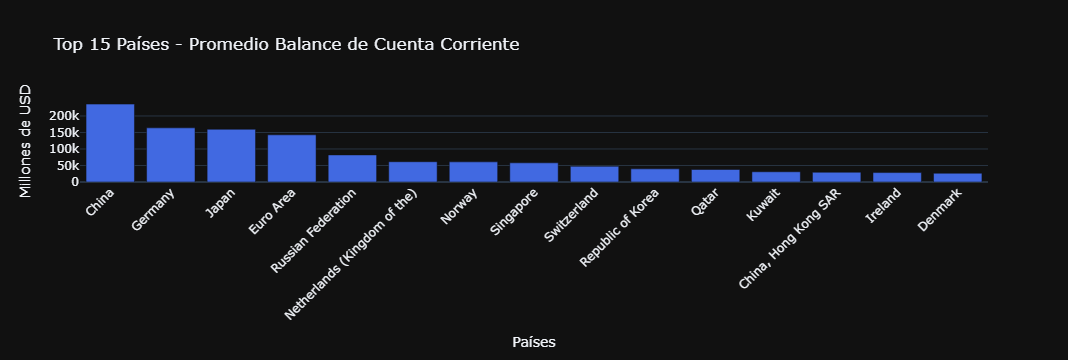

In [204]:
# Filtramos por una sola serie de datos
df_filtrado = df[df['Series'] == 'Balance of Payments: Current account (millions of US dollars)']

# Agrupamos por país y sacamos el promedio
df_agrupado = df_filtrado.groupby('Country')['Value'].mean().sort_values(ascending=False).head(15).reset_index()

# Graficamos los 15 paises con el mayor balance de pago
import plotly.graph_objects as go

fig1 = go.Figure()
fig1.add_trace(go.Bar(x = df_agrupado["Country"], y = df_agrupado["Value"], marker_color = "royalblue"))

fig1.update_layout(
    title = "Top 15 Países - Promedio Balance de Cuenta Corriente", xaxis_title = "Países", 
    yaxis_title = "Millones de USD", template = "plotly_dark")
fig1.update_layout(xaxis_tickangle=-45) 
fig1.show()

# Tip 2: Usar la visualización correcta

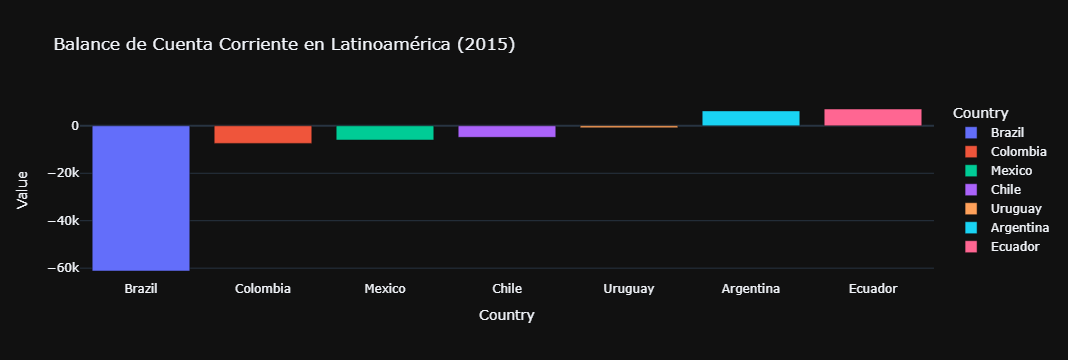

In [176]:
# Lista de países de Latinoamérica
latam = ['Mexico', 'Brazil', 'Argentina', 'Chile', 'Colombia', 'Peru', 'Ecuador', 'Uruguay']

# Filtramos el dataframe original
df_latam = df_2015[df_2015['Country'].isin(latam)]

# Graficamos
fig2 = px.bar(df_latam.sort_values('Value'), 
             x='Country', y='Value', 
             color='Country',
             title="Balance de Cuenta Corriente en Latinoamérica (2015)",
             template = "plotly_dark")
fig2.show()

# Tip 3: Enfatiza puntos clave

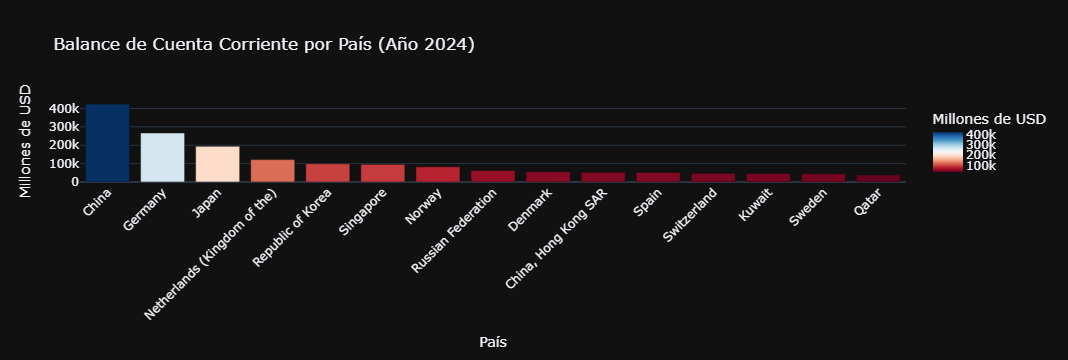

In [190]:
import pandas as pd
import plotly.express as px

# Filtramos los datos para el año más actual (2024) y solo la serie de "Current account"
serie = 'Balance of Payments: Current account (millions of US dollars)'
df_2024 = df[(df['Year'] == 2024) & (df['Series'] == serie)].copy()

# Ordenamos de mayor a menor para que el gráfico sea fácil de leer
df_2024 = df_2024.sort_values(by='Value', ascending=False)

# Tomamos los 15 países con el indice más alto
df_plot = pd.concat([df_2024.head(15)])

fig3 = px.bar(df_plot, x='Country', y='Value', title='Balance de Cuenta Corriente por País (Año 2024)', 
              labels={'Value': 'Millones de USD', 'Country': 'País'}, color='Value', color_continuous_scale='RdBu',
             template = "plotly_dark") 

fig3.update_layout(xaxis_tickangle=-45) 
fig3.show()

# Tip 5: Creación de un cuadro de control(Dashboard) para los gráficos previos

In [206]:
import dash
from dash import dcc
from dash import html

# Consolidación de graficos

app = dash.Dash(__name__)
app.layout = html.Div([
    html.H1('Cuadro de Control de Mando(Dashboard)', style={
        'color': 'white',}),

    html.Div([
        dcc.Graph(figure = fig1),
        dcc.Graph(figure = fig2),
    ], style = {'display': 'flex'}),

    html.Div([
        dcc.Graph(figure = fig3),
        #dcc.Graph(figure = fig4),
    ], style = {'display': 'flex'}),
])
if __name__ == '__main__':
    app.run(debug=True)